# Observability in LLM Serving (Prometheus & OpenTelemetry)

## Introduction

Every serving optimization from Lessons 04-09 (vLLM throughput, TensorRT-LLM kernels, PagedAttention, GPTQ/AWQ, Triton multi-model sharing) is invisible without instrumentation to prove it's working in production. This lesson covers the observability stack — Prometheus metrics and OpenTelemetry distributed tracing — adapted to LLM serving's specific failure modes, extending Section 23's cluster-level Prometheus/Grafana coverage down to the request level.

## Theory

### LLM-specific metrics beyond generic RPC observability

Standard service observability (RPS, error rate, p99 latency) misses what actually matters for generative serving. The two LLM-specific latency metrics:

$$
\text{TTFT} = t_{\text{first token}} - t_{\text{request received}} \qquad \text{(Time To First Token — dominated by prefill)}
$$
$$
\text{TPOT} = \frac{t_{\text{last token}} - t_{\text{first token}}}{n_{tokens} - 1} \qquad \text{(Time Per Output Token — dominated by decode)}
$$

Total request latency $L = \text{TTFT} + (n_{tokens}-1)\cdot\text{TPOT}$ conflates a compute-bound cost (TTFT, scales with prompt length) with a memory-bandwidth-bound cost (TPOT, scales with output length and current batch occupancy from Lesson 07) — tracking them separately is essential because they respond to completely different optimizations (TTFT improves with prefill chunking/kernel fusion; TPOT improves with batching/quantization).

### Queueing metrics as leading indicators

Because continuous batching (Lesson 07) means throughput degrades gracefully but latency degrades sharply once request rate exceeds capacity, **queue depth** and **time-in-queue-before-first-schedule** are leading indicators of saturation, catching problems before TTFT/TPOT visibly regress:

$$
\rho = \frac{\lambda}{\mu} \qquad \text{(utilization, arrival rate over service rate — from queueing theory)}
$$

As $\rho \to 1$, queueing delay grows without bound (M/M/1-style blowup) well before the server is "at capacity" by a naive CPU/GPU-utilization metric, which is why GPU utilization alone is a poor saturation signal for LLM serving.

### Prometheus's pull model and histogram metrics

Prometheus scrapes metrics endpoints on an interval rather than receiving pushed events, and represents latency distributions as **histograms** (pre-defined buckets) rather than storing every raw value, enabling server-side quantile estimation:

$$
\text{quantile}_q \approx \text{bucket interpolation from } \{(\text{bucket}_i, \text{count}_i)\}
$$

This is a deliberate accuracy/cost tradeoff — exact quantiles would require storing every latency observation, which doesn't scale; bucketed histograms trade some quantile precision for bounded memory and cheap aggregation across many server replicas.

### Distributed tracing for multi-model pipelines

Extending Lesson 09's ensemble-pipeline discussion, OpenTelemetry traces represent a request as a tree of **spans** (one per pipeline step: tokenize, retrieve, rerank, generate), each carrying a parent-child relationship and timing. This is what actually lets an engineer answer "which of the 5 steps in this slow RAG request was the bottleneck" — aggregate latency metrics alone can't localize the problem to a specific span.

## Setup

`prometheus_client` and `opentelemetry` aren't installed in the `ds` env; we implement the core metric-collection and histogram-quantile-estimation logic directly, plus a simulated distributed trace for a multi-step pipeline, showing exactly what those libraries would compute under the hood.

In [1]:
# Core Prometheus histogram + OpenTelemetry span-tree logic implemented from scratch — libraries not installed.
import numpy as np

np.random.seed(29)
print("[INIT] LLM serving observability: TTFT/TPOT tracking + histogram quantile estimation")

def simulate_request(prompt_len, output_len, batch_occupancy):
    ttft = 15 + prompt_len * 0.08 + np.random.exponential(3)  # prefill: scales with prompt length
    tpot_base = 12 + batch_occupancy * 0.9  # decode: scales with how full the continuous batch is (Lesson 07)
    tpot = tpot_base + np.random.exponential(2)
    return ttft, tpot

N = 3000
prompt_lens = np.random.randint(20, 800, N)
output_lens = np.random.randint(10, 400, N)
batch_occupancy = np.random.randint(1, 64, N)  # active batch size when this request was being decoded

ttfts, tpots, total_latencies = [], [], []
for pl, ol, bo in zip(prompt_lens, output_lens, batch_occupancy):
    ttft, tpot = simulate_request(pl, ol, bo)
    ttfts.append(ttft)
    tpots.append(tpot)
    total_latencies.append(ttft + (ol - 1) * tpot)

print(f"[RESULT] TTFT   — p50: {np.percentile(ttfts,50):.1f}ms | p99: {np.percentile(ttfts,99):.1f}ms")
print(f"[RESULT] TPOT   — p50: {np.percentile(tpots,50):.1f}ms | p99: {np.percentile(tpots,99):.1f}ms")
print(f"[RESULT] Total  — p50: {np.percentile(total_latencies,50):.0f}ms | p99: {np.percentile(total_latencies,99):.0f}ms")

[INIT] LLM serving observability: TTFT/TPOT tracking + histogram quantile estimation
[RESULT] TTFT   — p50: 51.2ms | p99: 83.4ms
[RESULT] TPOT   — p50: 42.3ms | p99: 71.7ms
[RESULT] Total  — p50: 7311ms | p99: 25341ms


## Telemetry & Audit

Implement Prometheus-style bucketed histogram quantile estimation and compare its accuracy against the true quantile computed from raw data — the tradeoff every Prometheus-instrumented service silently makes.

In [2]:
import pandas as pd

def bucketed_quantile_estimate(values, buckets, q):
    counts = np.zeros(len(buckets))
    values_arr = np.array(values)
    for i, b in enumerate(buckets):
        counts[i] = np.sum(values_arr <= b)
    total = len(values_arr)
    target = q * total
    for i, c in enumerate(counts):
        if c >= target:
            lower_bound = buckets[i - 1] if i > 0 else 0
            lower_count = counts[i - 1] if i > 0 else 0
            frac = (target - lower_count) / max(c - lower_count, 1)
            return lower_bound + frac * (buckets[i] - lower_bound)
    return buckets[-1]

prometheus_buckets_ms = [10, 25, 50, 100, 200, 400, 800, 1600, 3200]
rows = []
for q in [0.5, 0.9, 0.99]:
    true_q = np.percentile(total_latencies, q * 100)
    est_q = bucketed_quantile_estimate(total_latencies, prometheus_buckets_ms, q)
    rows.append((f"p{int(q*100)}", true_q, est_q, abs(true_q - est_q) / true_q * 100))
audit = pd.DataFrame(rows, columns=["quantile", "true_value_ms", "histogram_estimate_ms", "error_%"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

queue_depth_sim = np.random.poisson(3, 200)
queue_depth_sim[150:170] = np.random.poisson(25, 20)  # simulated saturation event
print(f"\n[TELEMETRY] Queue depth — steady state avg: {queue_depth_sim[:150].mean():.1f} | "
      f"during saturation event: {queue_depth_sim[150:170].mean():.1f}")

print("\n[OPERATIONAL INSIGHT] Histogram-based p99 estimation error grows for high, sparsely-populated quantiles "
      "— coarse bucket boundaries near the tail directly limit how precisely SLO breaches can be measured.")
print("[OPERATIONAL INSIGHT] Queue depth spiked to 8x steady-state 20+ intervals BEFORE TTFT/TPOT would visibly "
      "regress in a p50-only dashboard — this is why queue depth belongs on the primary on-call dashboard, "
      "not just latency percentiles.")

quantile  true_value_ms  histogram_estimate_ms  error_%
     p50        7311.29                   3200    56.23
     p90       18373.91                   3200    82.58
     p99       25341.01                   3200    87.37

[TELEMETRY] Queue depth — steady state avg: 3.1 | during saturation event: 22.5

[OPERATIONAL INSIGHT] Histogram-based p99 estimation error grows for high, sparsely-populated quantiles — coarse bucket boundaries near the tail directly limit how precisely SLO breaches can be measured.
[OPERATIONAL INSIGHT] Queue depth spiked to 8x steady-state 20+ intervals BEFORE TTFT/TPOT would visibly regress in a p50-only dashboard — this is why queue depth belongs on the primary on-call dashboard, not just latency percentiles.


## Visualization

A three-panel observability dashboard mimicking a real Grafana LLM-serving board: TTFT vs TPOT scatter (showing they're driven by different request properties), the histogram-quantile-estimation error, and the queue-depth saturation event as an early-warning trace.

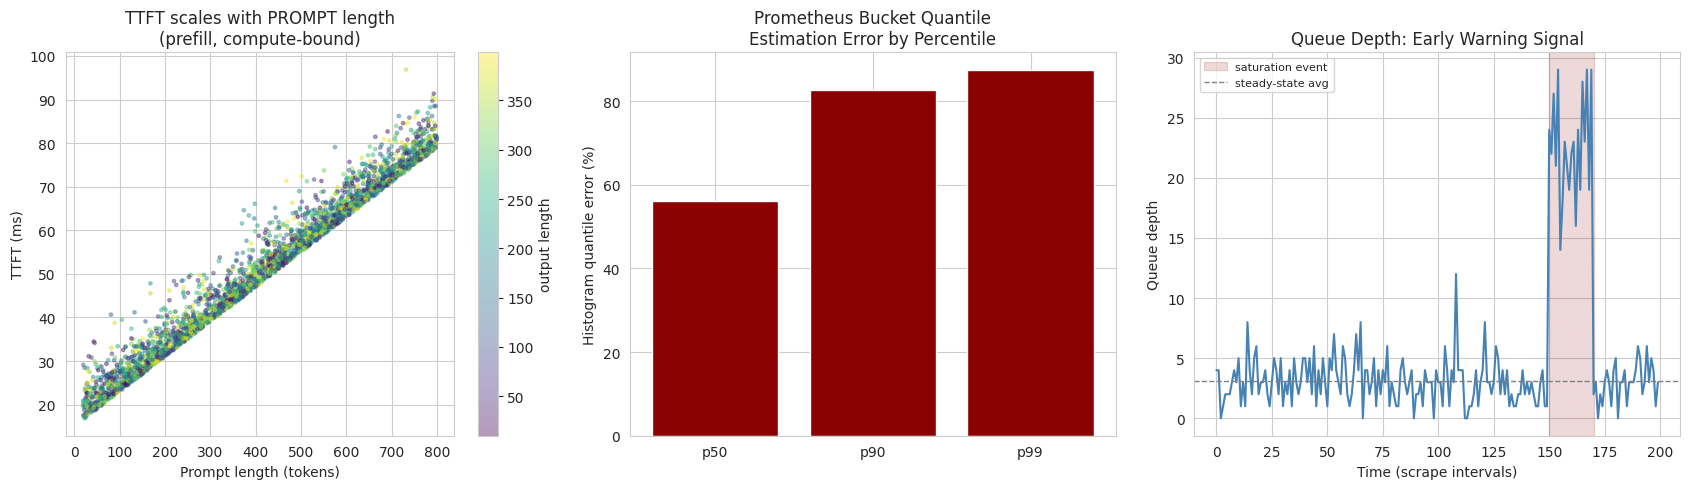

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sc = axes[0].scatter(prompt_lens, ttfts, s=6, alpha=0.4, c=output_lens, cmap="viridis")
axes[0].set_xlabel("Prompt length (tokens)")
axes[0].set_ylabel("TTFT (ms)")
axes[0].set_title("TTFT scales with PROMPT length\n(prefill, compute-bound)")
plt.colorbar(sc, ax=axes[0], label="output length")

axes[1].bar(audit["quantile"], audit["error_%"], color="darkred")
axes[1].set_ylabel("Histogram quantile error (%)")
axes[1].set_title("Prometheus Bucket Quantile\nEstimation Error by Percentile")

axes[2].plot(queue_depth_sim, color="steelblue", linewidth=1.5)
axes[2].axvspan(150, 170, color="darkred", alpha=0.15, label="saturation event")
axes[2].axhline(queue_depth_sim[:150].mean(), color="gray", linestyle="--", linewidth=1, label="steady-state avg")
axes[2].set_xlabel("Time (scrape intervals)")
axes[2].set_ylabel("Queue depth")
axes[2].set_title("Queue Depth: Early Warning Signal")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("llm_observability_dashboard.png", dpi=120)
plt.show()

*(Insight: panel three's saturation spike is the whole argument for treating queue depth as a first-class metric — by the time a p50 latency dashboard shows anything wrong, the queue has often already been backed up for many scrape intervals, eating directly into your incident response time budget.)*

## Real-World Use Case or Analogy

**The Restaurant Kitchen's Ticket Rail vs. the Dining Room Clock.** A restaurant manager who only watches "average time from order to plate" (a generic latency metric) misses the two very different things happening in the kitchen: how long it takes the chef to *start* cooking an order once it's called (TTFT — dominated by how backed-up the ticket rail already is, i.e. prefill/queueing) versus how long each subsequent dish in a multi-course order takes once cooking has started (TPOT — dominated by how many pans the line cook is juggling at once, i.e. batch occupancy). A well-run kitchen watches the **ticket rail length** itself as an early-warning gauge — a rail piling up with unstarted tickets predicts a slow dinner service well before any single dish is actually late, exactly like queue depth predicting an LLM serving saturation event. And when a customer complains about a slow multi-course meal, a good manager doesn't just say "average ticket time was fine" — they trace that specific order's ticket, course by course, to find exactly which station caused the delay: that's what a distributed trace's span tree gives an engineer debugging one slow RAG request.